<a href="https://colab.research.google.com/github/nehavelmurugan14-oss/DAA-exp-1-/blob/main/DAA_EXPE_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Items : [0.5, 0.7, 0.3, 0.9, 0.2, 0.6, 0.8, 0.4, 0.1, 0.5]
Capacity : 1.0
Total Size : 5.0
Lower Bound : 5

First Fit
Number of Bins = 6
Bin 1 : [0.5, 0.3, 0.2]  Used = 1.0
Bin 2 : [0.7, 0.1]  Used = 0.8
Bin 3 : [0.9]  Used = 0.9
Bin 4 : [0.6, 0.4]  Used = 1.0
Bin 5 : [0.8]  Used = 0.8
Bin 6 : [0.5]  Used = 0.5

First Fit Decreasing
Number of Bins = 6
Bin 1 : [0.9]  Used = 0.9
Bin 2 : [0.8, 0.1]  Used = 0.9
Bin 3 : [0.7, 0.3]  Used = 1.0
Bin 4 : [0.6, 0.4]  Used = 1.0
Bin 5 : [0.5, 0.5]  Used = 1.0
Bin 6 : [0.2]  Used = 0.2

Best Fit Decreasing
Number of Bins = 6
Bin 1 : [0.9]  Used = 0.9
Bin 2 : [0.8, 0.1]  Used = 0.9
Bin 3 : [0.7, 0.3]  Used = 1.0
Bin 4 : [0.6, 0.4]  Used = 1.0
Bin 5 : [0.5, 0.5]  Used = 1.0
Bin 6 : [0.2]  Used = 0.2

Summary
Lower Bound = 5
First Fit = 6
First Fit Decreasing = 6
Best Fit Decreasing = 6


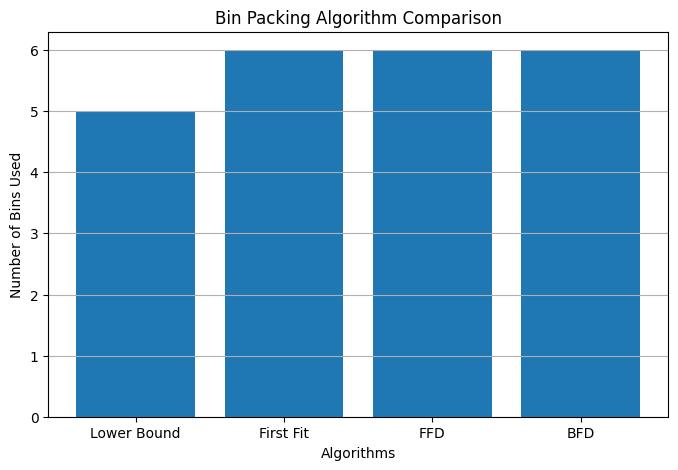

In [1]:
import matplotlib.pyplot as plt
import math

# ---------------- First Fit ----------------
def first_fit(items, capacity=1.0):

    bins = []
    bin_contents = []

    for item in items:

        placed = False

        for i in range(len(bins)):

            if bins[i] >= item:

                bins[i] -= item
                bin_contents[i].append(item)

                placed = True
                break

        if not placed:

            bins.append(capacity - item)
            bin_contents.append([item])

    return bin_contents


# ---------------- First Fit Decreasing ----------------
def first_fit_decreasing(items, capacity=1.0):

    items = sorted(items, reverse=True)

    return first_fit(items, capacity)


# ---------------- Best Fit Decreasing ----------------
def best_fit_decreasing(items, capacity=1.0):

    items = sorted(items, reverse=True)

    bins = []
    bin_contents = []

    for item in items:

        best = -1
        best_space = float('inf')

        for i in range(len(bins)):

            if bins[i] >= item and bins[i] - item < best_space:

                best_space = bins[i] - item
                best = i

        if best != -1:

            bins[best] -= item
            bin_contents[best].append(item)

        else:

            bins.append(capacity - item)
            bin_contents.append([item])

    return bin_contents


# ---------------- Display ----------------
def display_bins(name, bins):

    print(f"\n{name}")
    print("Number of Bins =", len(bins))

    for i, b in enumerate(bins, 1):

        used = sum(b)

        print(f"Bin {i} : {b}  Used = {used:.1f}")


# ---------------- Main ----------------

items = [0.5,0.7,0.3,0.9,0.2,0.6,0.8,0.4,0.1,0.5]

capacity = 1.0

lower_bound = math.ceil(sum(items)/capacity)

print("Items :", items)
print("Capacity :", capacity)
print("Total Size :", sum(items))
print("Lower Bound :", lower_bound)

ff = first_fit(items, capacity)
ffd = first_fit_decreasing(items, capacity)
bfd = best_fit_decreasing(items, capacity)

display_bins("First Fit", ff)
display_bins("First Fit Decreasing", ffd)
display_bins("Best Fit Decreasing", bfd)

print("\nSummary")
print("Lower Bound =", lower_bound)
print("First Fit =", len(ff))
print("First Fit Decreasing =", len(ffd))
print("Best Fit Decreasing =", len(bfd))


# ---------------- Graph ----------------

algorithms = ["Lower Bound", "First Fit", "FFD", "BFD"]

bins_used = [
    lower_bound,
    len(ff),
    len(ffd),
    len(bfd)
]

plt.figure(figsize=(8,5))

plt.bar(algorithms, bins_used)

plt.title("Bin Packing Algorithm Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Number of Bins Used")
plt.grid(axis='y')

plt.show()